

EXPERIMENTO PADRÃO

========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


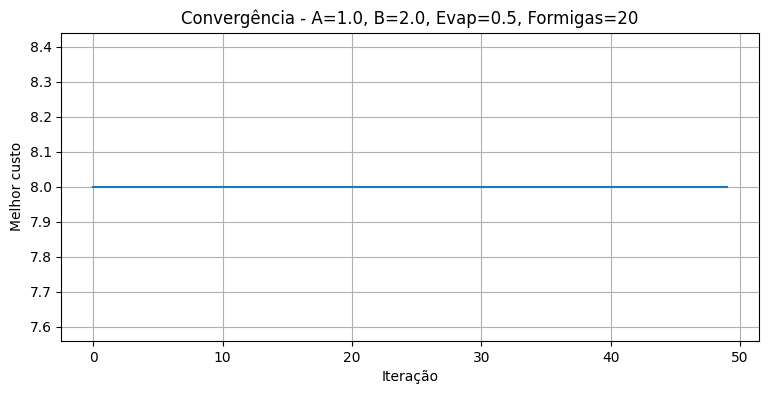

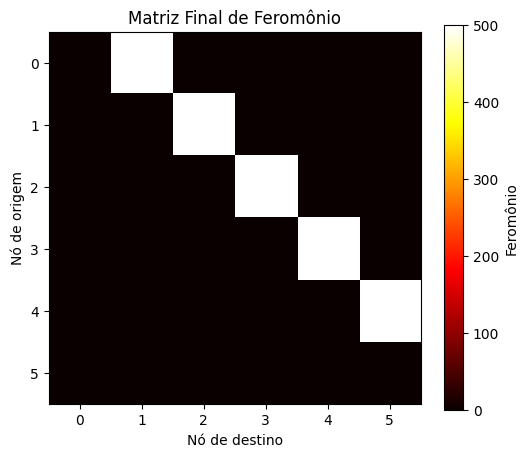



EXPERIMENTO 1 — ALPHA = 0.1

========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 0.1
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


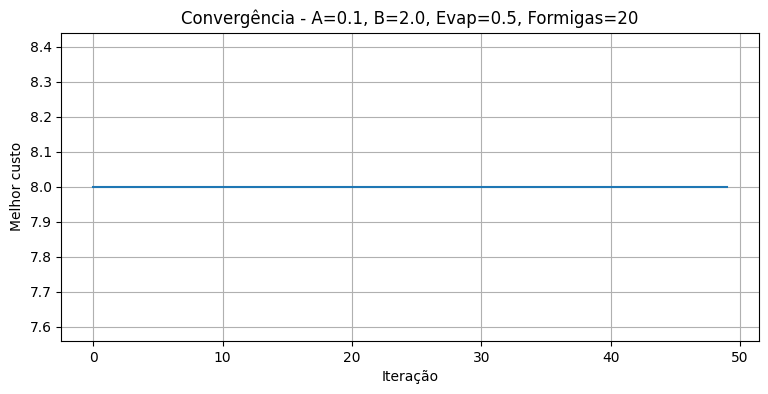

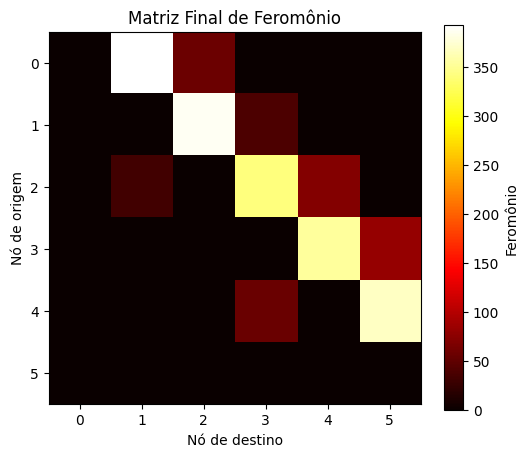



EXPERIMENTO 1 — ALPHA = 5.0

========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 5.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


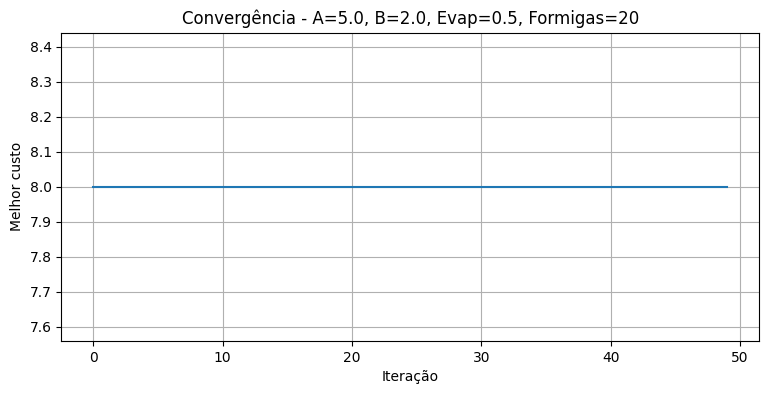

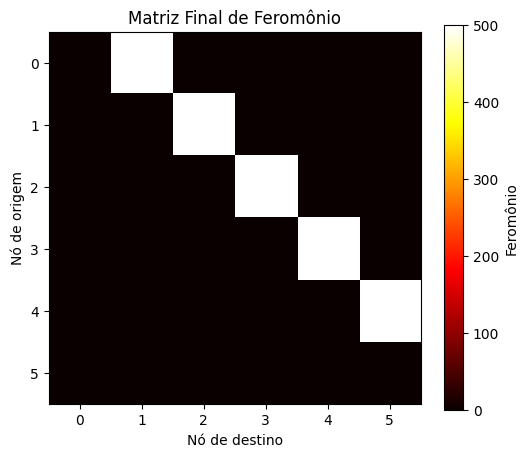



EXPERIMENTO 2 — BETA = 0.5

========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 0.5
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


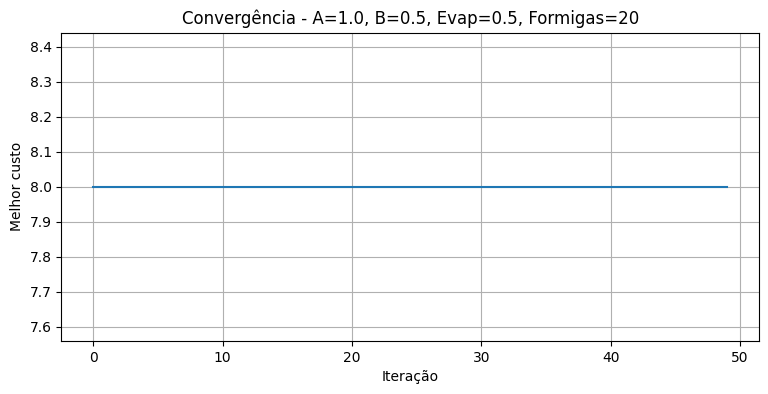

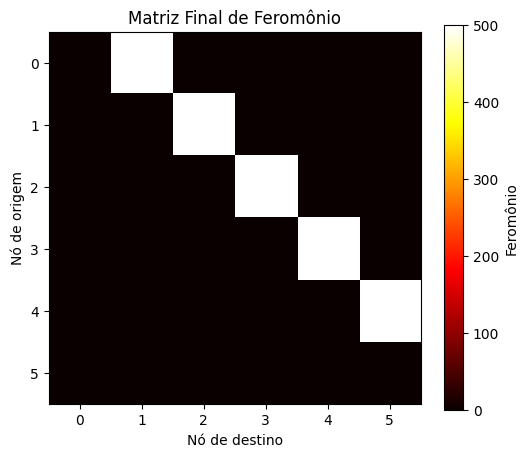



EXPERIMENTO 2 — BETA = 5.0

========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 5.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


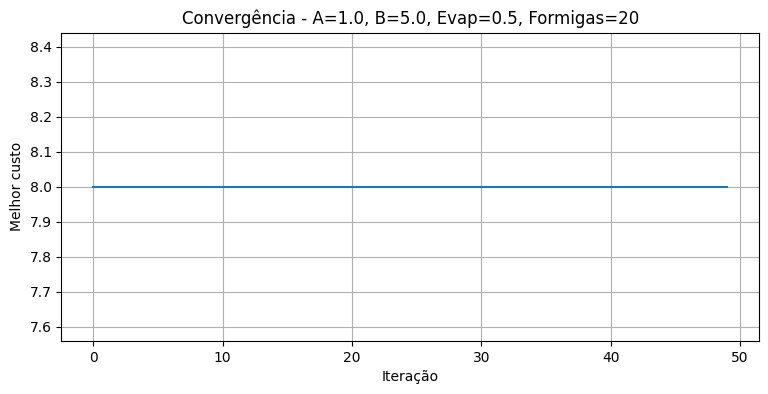

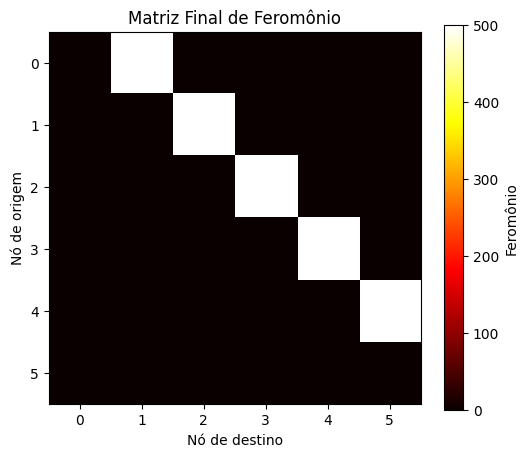



EXPERIMENTO 3 — EVAPORAÇÃO = 0.1

========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.1
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


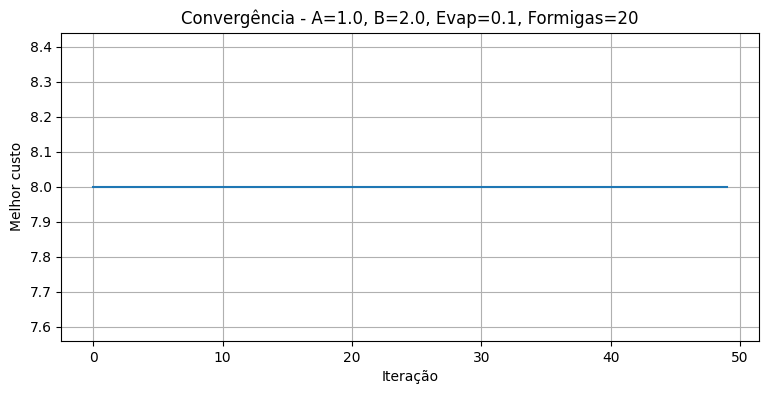

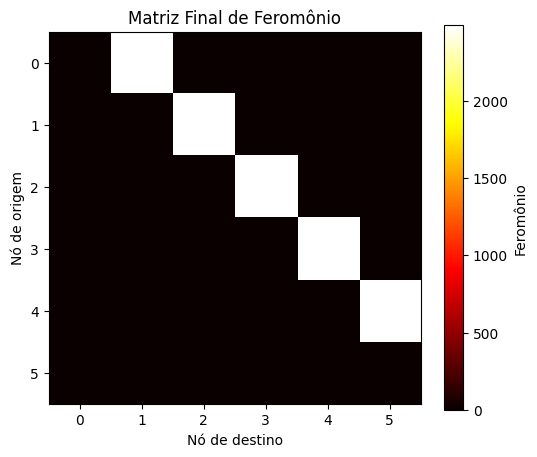



EXPERIMENTO 3 — EVAPORAÇÃO = 0.9

========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.9
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


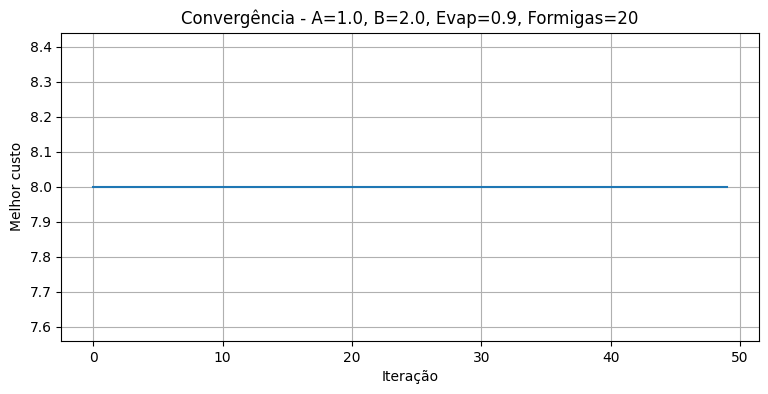

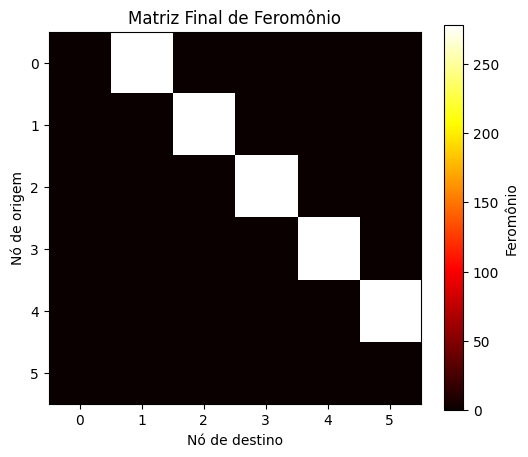



EXPERIMENTO 4 — 5 FORMIGAS

========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 5
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


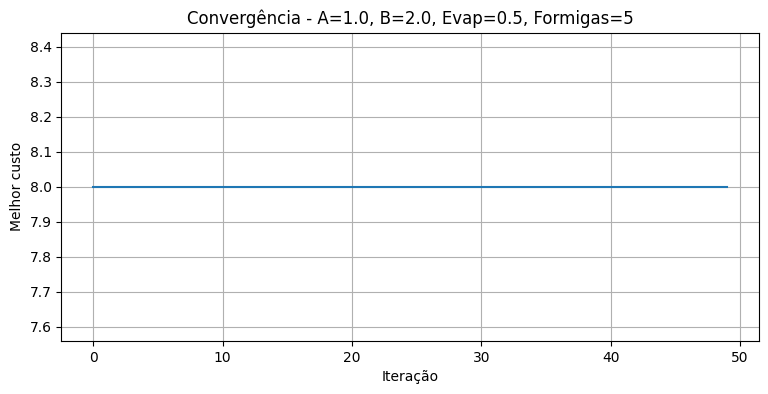

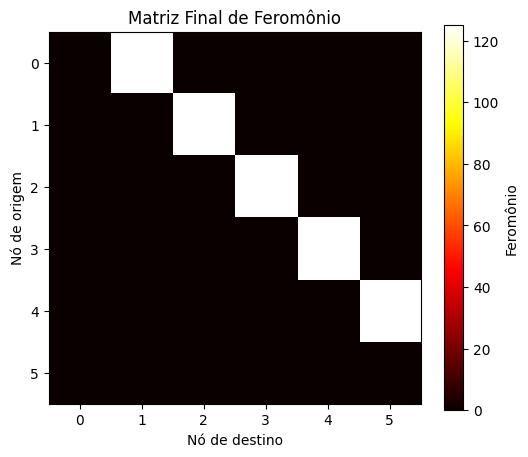



EXPERIMENTO 4 — 50 FORMIGAS

========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 50
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


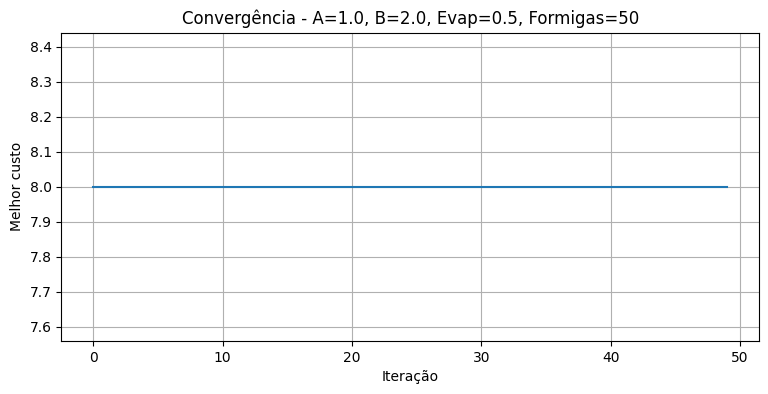

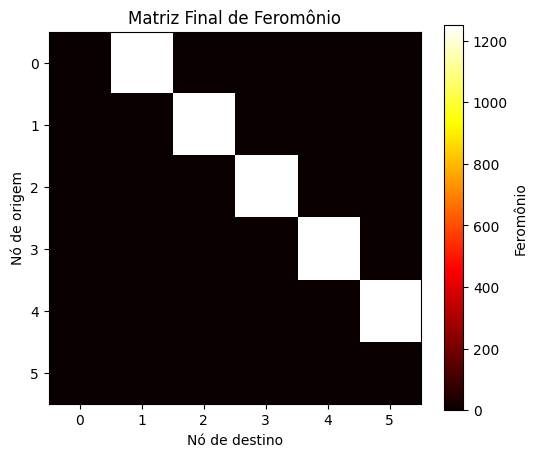



             RESUMO DOS EXPERIMENTOS
Padrão -> [0, 1, 2, 3, 4, 5] | Custo: 8.0
ALPHA 0.1 -> [0, 1, 2, 3, 4, 5] | Custo: 8.0
ALPHA 5.0 -> [0, 1, 2, 3, 4, 5] | Custo: 8.0
BETA 0.5 -> [0, 1, 2, 3, 4, 5] | Custo: 8.0
BETA 5.0 -> [0, 1, 2, 3, 4, 5] | Custo: 8.0
Evaporação 0.1 -> [0, 1, 2, 3, 4, 5] | Custo: 8.0
Evaporação 0.9 -> [0, 1, 2, 3, 4, 5] | Custo: 8.0
5 formigas -> [0, 1, 2, 3, 4, 5] | Custo: 8.0
50 formigas -> [0, 1, 2, 3, 4, 5] | Custo: 8.0


In [1]:
# ============================================================
# LABORATÓRIO 02 — EXPERIMENTANDO O ACO
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt


# ============================================================
# REDE DO PROBLEMA
# ============================================================

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5


# ============================================================
# FUNÇÃO PRINCIPAL DO ACO
# ============================================================

def executar_aco(
    NUM_FORMIGAS=20,
    NUM_ITERACOES=50,
    ALPHA=1.0,
    BETA=2.0,
    TAXA_EVAPORACAO=0.5,
    Q=100,
    seed=42,
    mostrar_graficos=True
):

    # Mantém os experimentos reproduzíveis
    random.seed(seed)
    np.random.seed(seed)

    # Matriz inicial de feromônio
    feromonio = np.ones_like(CUSTOS, dtype=float)

    # Remove feromônio onde não existe ligação
    feromonio[CUSTOS == np.inf] = 0

    # Remove diagonal
    np.fill_diagonal(feromonio, 0)


    # ========================================================
    # OBTÉM VIZINHOS
    # ========================================================

    def obter_vizinhos(no):

        vizinhos = []

        for proximo in range(len(CUSTOS)):

            if (
                proximo != no
                and CUSTOS[no][proximo] != np.inf
            ):

                vizinhos.append(proximo)

        return vizinhos


    # ========================================================
    # ESCOLHE PRÓXIMO NÓ
    # ========================================================

    def escolher_proximo(no_atual, visitados):

        vizinhos = obter_vizinhos(no_atual)

        candidatos = [
            no for no in vizinhos
            if no not in visitados
        ]

        if not candidatos:
            return None

        atratividades = []

        for proximo in candidatos:

            fer = feromonio[no_atual][proximo]
            custo = CUSTOS[no_atual][proximo]

            atratividade = (
                (fer ** ALPHA)
                *
                ((1 / custo) ** BETA)
            )

            atratividades.append(atratividade)

        soma = sum(atratividades)

        if soma == 0:
            return random.choice(candidatos)

        probabilidades = [
            valor / soma
            for valor in atratividades
        ]

        return random.choices(
            candidatos,
            weights=probabilidades,
            k=1
        )[0]


    # ========================================================
    # CONSTRÓI UMA ROTA
    # ========================================================

    def construir_rota():

        rota = [ORIGEM]

        atual = ORIGEM

        while atual != DESTINO:

            proximo = escolher_proximo(
                atual,
                rota
            )

            if proximo is None:
                return None

            rota.append(proximo)

            atual = proximo

        return rota


    # ========================================================
    # CALCULA CUSTO
    # ========================================================

    def calcular_custo(rota):

        total = 0

        for i in range(len(rota) - 1):

            origem = rota[i]
            destino = rota[i + 1]

            total += CUSTOS[origem][destino]

        return total


    # ========================================================
    # EVAPORA FEROMÔNIO
    # ========================================================

    def evaporar_feromonio():

        nonlocal feromonio

        feromonio *= (
            1 - TAXA_EVAPORACAO
        )

        feromonio[CUSTOS == np.inf] = 0

        np.fill_diagonal(
            feromonio,
            0
        )


    # ========================================================
    # DEPÓSITO DE FEROMÔNIO
    # ========================================================

    def depositar_feromonio(
        rota,
        custo
    ):

        deposito = Q / custo

        for i in range(len(rota) - 1):

            origem = rota[i]
            destino = rota[i + 1]

            feromonio[
                origem
            ][
                destino
            ] += deposito


    # ========================================================
    # EXECUÇÃO DO ACO
    # ========================================================

    melhor_rota = None
    melhor_custo = float("inf")

    historico = []

    for iteracao in range(
        NUM_ITERACOES
    ):

        rotas = []

        for _ in range(
            NUM_FORMIGAS
        ):

            rota = construir_rota()

            if rota is not None:

                custo = calcular_custo(
                    rota
                )

                rotas.append(
                    (rota, custo)
                )

                if custo < melhor_custo:

                    melhor_custo = custo

                    melhor_rota = (
                        rota.copy()
                    )

        # Evaporação
        evaporar_feromonio()

        # Depósito
        for rota, custo in rotas:

            depositar_feromonio(
                rota,
                custo
            )

        historico.append(
            melhor_custo
        )


    # ========================================================
    # RESULTADO
    # ========================================================

    print(
        "\n=============================================="
    )

    print(
        "========== RESULTADO DO EXPERIMENTO =========="
    )

    print(
        "Número de formigas:",
        NUM_FORMIGAS
    )

    print(
        "Número de iterações:",
        NUM_ITERACOES
    )

    print(
        "ALPHA:",
        ALPHA
    )

    print(
        "BETA:",
        BETA
    )

    print(
        "Taxa de evaporação:",
        TAXA_EVAPORACAO
    )

    print(
        "Melhor rota:",
        melhor_rota
    )

    print(
        "Melhor custo:",
        melhor_custo
    )


    # ========================================================
    # GRÁFICOS
    # ========================================================

    if mostrar_graficos:

        # Curva de convergência
        plt.figure(
            figsize=(9, 4)
        )

        plt.plot(
            historico
        )

        plt.xlabel(
            "Iteração"
        )

        plt.ylabel(
            "Melhor custo"
        )

        plt.title(
            f"Convergência - "
            f"A={ALPHA}, "
            f"B={BETA}, "
            f"Evap={TAXA_EVAPORACAO}, "
            f"Formigas={NUM_FORMIGAS}"
        )

        plt.grid()

        plt.show()


        # Matriz de feromônio
        plt.figure(
            figsize=(6, 5)
        )

        plt.imshow(
            feromonio,
            cmap="hot"
        )

        plt.colorbar(
            label="Feromônio"
        )

        plt.xlabel(
            "Nó de destino"
        )

        plt.ylabel(
            "Nó de origem"
        )

        plt.title(
            "Matriz Final de Feromônio"
        )

        plt.xticks(
            range(len(CUSTOS))
        )

        plt.yticks(
            range(len(CUSTOS))
        )

        plt.show()


    return {
        "melhor_rota": melhor_rota,
        "melhor_custo": melhor_custo,
        "historico": historico,
        "feromonio": feromonio
    }


# ============================================================
# EXPERIMENTO PADRÃO
# ============================================================

print("\n\nEXPERIMENTO PADRÃO")

resultado_padrao = executar_aco(
    NUM_FORMIGAS=20,
    NUM_ITERACOES=50,
    ALPHA=1.0,
    BETA=2.0,
    TAXA_EVAPORACAO=0.5,
    Q=100
)


# ============================================================
# EXPERIMENTO 1 — ALPHA BAIXO
# ============================================================

print("\n\nEXPERIMENTO 1 — ALPHA = 0.1")

resultado_alpha_baixo = executar_aco(
    NUM_FORMIGAS=20,
    NUM_ITERACOES=50,
    ALPHA=0.1,
    BETA=2.0,
    TAXA_EVAPORACAO=0.5,
    Q=100
)


# ============================================================
# EXPERIMENTO 1 — ALPHA ALTO
# ============================================================

print("\n\nEXPERIMENTO 1 — ALPHA = 5.0")

resultado_alpha_alto = executar_aco(
    NUM_FORMIGAS=20,
    NUM_ITERACOES=50,
    ALPHA=5.0,
    BETA=2.0,
    TAXA_EVAPORACAO=0.5,
    Q=100
)


# ============================================================
# EXPERIMENTO 2 — BETA BAIXO
# ============================================================

print("\n\nEXPERIMENTO 2 — BETA = 0.5")

resultado_beta_baixo = executar_aco(
    NUM_FORMIGAS=20,
    NUM_ITERACOES=50,
    ALPHA=1.0,
    BETA=0.5,
    TAXA_EVAPORACAO=0.5,
    Q=100
)


# ============================================================
# EXPERIMENTO 2 — BETA ALTO
# ============================================================

print("\n\nEXPERIMENTO 2 — BETA = 5.0")

resultado_beta_alto = executar_aco(
    NUM_FORMIGAS=20,
    NUM_ITERACOES=50,
    ALPHA=1.0,
    BETA=5.0,
    TAXA_EVAPORACAO=0.5,
    Q=100
)


# ============================================================
# EXPERIMENTO 3 — EVAPORAÇÃO BAIXA
# ============================================================

print("\n\nEXPERIMENTO 3 — EVAPORAÇÃO = 0.1")

resultado_evap_baixa = executar_aco(
    NUM_FORMIGAS=20,
    NUM_ITERACOES=50,
    ALPHA=1.0,
    BETA=2.0,
    TAXA_EVAPORACAO=0.1,
    Q=100
)


# ============================================================
# EXPERIMENTO 3 — EVAPORAÇÃO ALTA
# ============================================================

print("\n\nEXPERIMENTO 3 — EVAPORAÇÃO = 0.9")

resultado_evap_alta = executar_aco(
    NUM_FORMIGAS=20,
    NUM_ITERACOES=50,
    ALPHA=1.0,
    BETA=2.0,
    TAXA_EVAPORACAO=0.9,
    Q=100
)


# ============================================================
# EXPERIMENTO 4 — POUCAS FORMIGAS
# ============================================================

print("\n\nEXPERIMENTO 4 — 5 FORMIGAS")

resultado_5_formigas = executar_aco(
    NUM_FORMIGAS=5,
    NUM_ITERACOES=50,
    ALPHA=1.0,
    BETA=2.0,
    TAXA_EVAPORACAO=0.5,
    Q=100
)


# ============================================================
# EXPERIMENTO 4 — MUITAS FORMIGAS
# ============================================================

print("\n\nEXPERIMENTO 4 — 50 FORMIGAS")

resultado_50_formigas = executar_aco(
    NUM_FORMIGAS=50,
    NUM_ITERACOES=50,
    ALPHA=1.0,
    BETA=2.0,
    TAXA_EVAPORACAO=0.5,
    Q=100
)


# ============================================================
# RESUMO FINAL
# ============================================================

print("\n\n==============================================")
print("             RESUMO DOS EXPERIMENTOS")
print("==============================================")

print(
    "Padrão ->",
    resultado_padrao["melhor_rota"],
    "| Custo:",
    resultado_padrao["melhor_custo"]
)

print(
    "ALPHA 0.1 ->",
    resultado_alpha_baixo["melhor_rota"],
    "| Custo:",
    resultado_alpha_baixo["melhor_custo"]
)

print(
    "ALPHA 5.0 ->",
    resultado_alpha_alto["melhor_rota"],
    "| Custo:",
    resultado_alpha_alto["melhor_custo"]
)

print(
    "BETA 0.5 ->",
    resultado_beta_baixo["melhor_rota"],
    "| Custo:",
    resultado_beta_baixo["melhor_custo"]
)

print(
    "BETA 5.0 ->",
    resultado_beta_alto["melhor_rota"],
    "| Custo:",
    resultado_beta_alto["melhor_custo"]
)

print(
    "Evaporação 0.1 ->",
    resultado_evap_baixa["melhor_rota"],
    "| Custo:",
    resultado_evap_baixa["melhor_custo"]
)

print(
    "Evaporação 0.9 ->",
    resultado_evap_alta["melhor_rota"],
    "| Custo:",
    resultado_evap_alta["melhor_custo"]
)

print(
    "5 formigas ->",
    resultado_5_formigas["melhor_rota"],
    "| Custo:",
    resultado_5_formigas["melhor_custo"]
)

print(
    "50 formigas ->",
    resultado_50_formigas["melhor_rota"],
    "| Custo:",
    resultado_50_formigas["melhor_custo"]
)